# MLflow Experiment Tracking — Maré Hotels' cancellation model

**Every model you train becomes a run you can find, compare, reload and reproduce.**

- **The business:** Maré Hotels runs a city hotel in Lisbon and a resort in the Algarve. 37% of bookings get cancelled — rooms that could have been resold.
- **The model:** score each upcoming booking with P(cancel), so the revenue team can reconfirm risky bookings and overbook safely.
- **The catch:** seven candidate models, three model families, a size budget from the platform team — and months later someone will ask exactly which model shipped, and why.

| Part | Case-study step | MLflow you use |
|---|---|---|
| P1 | Load the bookings, train a model the untracked way | why tracking exists |
| P2 | Track the baseline | tracking URI · experiment · run · params · metrics · tags |
| P3 | Sweep seven configurations | many runs · metrics with steps (training curves) |
| P4 | Pick the winner under a 50 MB budget | MLflow UI: sort, chart, compare · `mlflow.search_runs()` |
| P5 | Retrain the winner, score it on the test set | artifacts: plots, reports, tables |
| P6 | Package it | `mlflow.sklearn.log_model()` · signature · input example |
| P7 | Score next week's arrivals | `load_model` (pyfunc vs sklearn flavor) · schema enforcement |
| P8 | Cut the boilerplate | autologging · manual vs autolog · parent/child runs |
| P9 | Move training into a script | `train.py` · dataset lineage · git commit · reproducibility |
| P10 | What bites in practice | run IDs vs names · run status · tracking-URI consistency · local vs shared server |
| P11 | Wrap-up | tracking vs registry vs serving · recap · recommendations · what comes next |

## The map

```
          MARÉ HOTELS — from an untracked notebook to a tracked training pipeline

  data/bookings_2015_2017.csv.gz ··· 118,300 bookings with a known outcome (is_canceled)
      │
      ▼
  [P1] build_pipeline() + evaluate() on a 60/20/20 split ──► untracked: "which run was it?"
      │
      ▼
  [P2] mlflow.set_tracking_uri("sqlite:///mlflow.db")   ◄── mlflow ui ... --port 5001
       mlflow.set_experiment("booking-cancellations")        (your own terminal)
       run "baseline-logreg" ── params · metrics · tags
      │
      ▼
  [P3] 7 runs tagged stage=sweep ── val_* · fit_time_s · model_size_mb · config.json
       hist_gb runs also log train_loss / holdout_loss per boosting round (step=)
      │
      ▼
  [P4] UI: sort · scatter · compare    mlflow.search_runs("... metrics.model_size_mb < 50",
      │                                                   order_by=val_roc_auc DESC)
      │                                └──► best_params ◄── runs:/<best_run_id>/config.json
      ▼
  [P5] run "final-hist_gb": train+val → test ── plots/ · eval/ artifacts
  [P6] mlflow.sklearn.log_model(...) ──► models:/m-…  + signature + input example
      │
      ▼
  [P7] mlflow.pyfunc / mlflow.sklearn.load_model ──► risk list for upcoming_arrivals.csv
      │                                          ──► bad requests stopped by the signature
      ▼
  [P8] mlflow.sklearn.autolog()  what it logs for free · what it can't know · parent/child
  [P9] python train.py ...       same experiment, from a terminal; reproduces P5's test score
  [P10] run IDs vs names · RUNNING/FINISHED/FAILED · one tracking URI · local vs shared
      │
      ▼
  ┌──────────────────────────────────────────────────────────────────────────────┐
  │ END RESULT: every model tried is a run you can find, compare, reload and     │
  │ reproduce, and train.py makes tracking the default instead of a habit.       │
  └──────────────────────────────────────────────────────────────────────────────┘
```

## P0 · Setup

```
[▶ SETUP] → problem → first run → sweep → compare → artifacts → log model → load model
→ autolog → train.py → practice → wrap-up
```

*You are here → **Part 0 of 11**: install the pinned versions and import everything once.*

**Everything this notebook needs sits beside it: `requirements.txt`, `data/`, `train.py`.**

- `requirements.txt` pins MLflow — its UI and defaults (model serialization, the default store) move between minor versions.
- Start `mlflow ui` (P2) from the same Python environment this notebook runs in.

In [1]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autotime

time: 94.7 µs (started: 2026-09-28 10:49:13 +05:30)


In [3]:
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import sklearn
from mlflow import MlflowClient
from mlflow.models import infer_signature
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print(f"mlflow {mlflow.__version__} · scikit-learn {sklearn.__version__} · pandas {pd.__version__}")

mlflow 3.16.1 · scikit-learn 1.7.2 · pandas 2.3.3
time: 2.13 s (started: 2026-09-28 10:49:13 +05:30)


## P1 · The problem: bookings that cancel

```
setup ✓ → [▶ PROBLEM] → first run → sweep → compare → artifacts → log model → load model
→ autolog → train.py → practice → wrap-up
```

*You are here → **Part 1 of 11**: meet the data, then train a model the untracked way.*

**118,300 past bookings with a known outcome: the model learns which bookings cancel.**

- One row per booking, arrivals from July 2015 to August 2017.
- `is_canceled` is the target; everything else was known when the booking was made.

In [4]:
bookings = pd.read_csv("data/bookings_2015_2017.csv.gz")

print(f"{len(bookings):,} bookings · arrivals {bookings.arrival_date.min()} → {bookings.arrival_date.max()}")
print(f"cancelled: {bookings.is_canceled.mean():.1%}")
bookings.head()

118,300 bookings · arrivals 2015-07-01 → 2017-08-24
cancelled: 37.1%


,booking_id,arrival_date,hotel,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,...,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,is_canceled
0,BK100001,2015-07-01,City Hotel,6,0,2,1,0.0,0,HB,...,0,0,A,No Deposit,Transient,0,0.0,0,0,0
1,BK100002,2015-07-01,City Hotel,88,0,4,2,0.0,0,BB,...,0,0,A,No Deposit,Transient,0,76.5,0,1,1
2,BK100003,2015-07-01,City Hotel,65,0,4,1,0.0,0,BB,...,0,0,A,No Deposit,Transient,0,68.0,0,1,1
3,BK100004,2015-07-01,City Hotel,92,2,4,2,0.0,0,BB,...,0,0,A,No Deposit,Transient,0,76.5,0,2,1
4,BK100005,2015-07-01,City Hotel,257,0,2,2,0.0,0,HB,...,1,0,A,No Deposit,Transient,0,101.5,0,0,1


time: 123 ms (started: 2026-09-28 10:49:15 +05:30)


### What the columns mean

**Twenty model inputs, two identifiers, one target.**

| Column | Meaning |
|---|---|
| `booking_id`, `arrival_date` | identifiers — not model inputs |
| `hotel` | `City Hotel` (Lisbon) or `Resort Hotel` (Algarve) |
| `lead_time` | days between making the booking and the arrival date |
| `stays_in_weekend_nights`, `stays_in_week_nights` | length of stay, split into weekend and weekday nights |
| `adults`, `children`, `babies` | party size |
| `meal` | `BB` bed & breakfast · `HB` half board · `FB` full board · `SC` / `Undefined` no meal package |
| `market_segment` | how the booking was sold: `Online TA` (online travel agent), `Offline TA/TO` (travel agent / tour operator), `Groups`, `Direct`, `Corporate`, `Complementary`, `Aviation` |
| `distribution_channel` | `TA/TO`, `Direct`, `Corporate`, `GDS` (global distribution system) |
| `is_repeated_guest` | `1` = the guest has stayed before |
| `previous_cancellations`, `previous_bookings_not_canceled` | the guest's booking history |
| `reserved_room_type` | room category, as an anonymised letter code (`A` … `L`) |
| `deposit_type` | `No Deposit` · `Non Refund` (paid in full, no refund) · `Refundable` |
| `customer_type` | `Transient` (individual) · `Transient-Party` (linked to another booking) · `Contract` · `Group` |
| `days_in_waiting_list` | days the booking waited before it was confirmed |
| `adr` | average daily rate, EUR |
| `required_car_parking_spaces`, `total_of_special_requests` | extras the guest asked for |
| `is_canceled` | **target** — `1` = cancelled |

*Source: Hotel Booking Demand dataset — Antonio, de Almeida & Nunes, Data in Brief (2019), CC BY 4.0.*

### One split, one pipeline, one scoring function

**Every run in this notebook trains through the same two functions, so runs differ only in the settings they log.**

- `build_pipeline(params)` — median-impute + scale the numbers, one-hot the categories, then the model named in `params["model_type"]`.
- `evaluate(pipe, X, y)` — ROC-AUC and PR-AUC (how well it ranks bookings), plus F1, precision and recall at the 0.5 threshold the revenue team acts on.
- The test set (20%) stays untouched until the final model in P5.

In [5]:
NUMERIC = [
    "lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children",
    "babies", "is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled",
    "days_in_waiting_list", "adr", "required_car_parking_spaces", "total_of_special_requests",
]
CATEGORICAL = [
    "hotel", "meal", "market_segment", "distribution_channel", "reserved_room_type",
    "deposit_type", "customer_type",
]
FEATURES = NUMERIC + CATEGORICAL
SEED = 42

X, y = bookings[FEATURES], bookings["is_canceled"]
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=SEED)

print(f"train {len(X_train):,} · validation {len(X_val):,} · test {len(X_test):,} · {len(FEATURES)} features")

train 70,980 · validation 23,660 · test 23,660 · 20 features
time: 36.7 ms (started: 2026-09-28 10:49:15 +05:30)


In [6]:
def build_pipeline(params):
    # params = {"model_type": ..., **hyperparameters}  →  an untrained preprocessing + model Pipeline
    hyper = {k: v for k, v in params.items() if k != "model_type"}
    if params["model_type"] == "logreg":
        model = LogisticRegression(max_iter=1000, **hyper)
    elif params["model_type"] == "random_forest":
        model = RandomForestClassifier(n_jobs=-1, random_state=SEED, **hyper)
    elif params["model_type"] == "hist_gb":
        model = HistGradientBoostingClassifier(random_state=SEED, **hyper)
    prep = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ])
    return Pipeline([("prep", prep), ("model", model)])


def evaluate(pipe, X, y, prefix="val"):
    proba = pipe.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        f"{prefix}_roc_auc": roc_auc_score(y, proba),
        f"{prefix}_pr_auc": average_precision_score(y, proba),
        f"{prefix}_f1": f1_score(y, pred),
        f"{prefix}_precision": precision_score(y, pred),
        f"{prefix}_recall": recall_score(y, pred),
    }

time: 553 µs (started: 2026-09-28 10:49:15 +05:30)


### The untracked way

**This is how most experiments start: change a number, run the cell, read the printout.**

In [7]:
for C in [0.1, 1.0]:
    pipe = build_pipeline({"model_type": "logreg", "C": C}).fit(X_train, y_train)
    print(f"logreg C={C}:  val ROC-AUC {evaluate(pipe, X_val, y_val)['val_roc_auc']:.4f}")

logreg C=0.1:  val ROC-AUC 0.8471


logreg C=1.0:  val ROC-AUC 0.8474
time: 559 ms (started: 2026-09-28 10:49:15 +05:30)


### What that printout can't tell you

**The numbers are real; everything around them is already being lost.**

- **Which settings produced them?** Only this cell knows — until someone edits it.
- **Where is the fitted model?** In memory. Restart the kernel and it's gone.
- **Which of last month's 40 runs had the best PR-AUC?** Nobody wrote it down.
- **Who ran it, when, on which code version, and how long did it take?** Unknown.
- **Experiment tracking** fixes this: every training run records its inputs (code, data, parameters), outputs (metrics, plots, model) and context (who, when, where) in a store you can browse and query.

💬 **Think about it** — Take your best model from last quarter. Could you retrain exactly that model right now? List what you would need that isn't in the notebook.

## P2 · Track the baseline

```
setup ✓ → problem ✓ → [▶ FIRST RUN] → sweep → compare → artifacts → log model → load model
→ autolog → train.py → practice → wrap-up
```

*You are here → **Part 2 of 11**: point MLflow at a store and record the first run.*

**MLflow groups runs into experiments; each run records parameters, metrics, tags and artifacts.**

| Concept | What it is | In this notebook | Logged with |
|---|---|---|---|
| **Experiment** | a named group of runs for one prediction problem | `booking-cancellations` | `mlflow.set_experiment()` |
| **Run** | one execution of training code | `baseline-logreg`, `rf-200-d30`, … | `mlflow.start_run()` |
| **Parameter** | an input you chose — written once per run, stored as a string | `C = 1.0`, `max_depth = 30` | `mlflow.log_param()` / `log_params()` |
| **Metric** | a numeric result — log it again with a `step` and it becomes a curve | `val_roc_auc`, `holdout_loss` | `mlflow.log_metric()` / `log_metrics()` |
| **Tag** | an editable label for organising and filtering runs | `stage = sweep` | `mlflow.set_tag()` / `set_tags()` |
| **Artifact** | any file: plot, report, config, data sample | `plots/test_evaluation.png` | `log_figure()`, `log_dict()`, `log_text()`, `log_artifact()` |
| **Logged model** | a model packaged with its signature and environment | `models:/m-…` | `mlflow.sklearn.log_model()` |

### Where it all lives

**Code writes to a store through the tracking URI; the UI is just another reader of that store.**

```mermaid
flowchart LR
    CODE(["notebook · train.py<br/>mlflow client"])
    DB[("backend store: mlflow.db<br/>experiments · runs<br/>params · metrics · tags")]
    FILES[("artifact store: mlruns/<br/>plots · reports · models")]
    UI(["mlflow ui<br/>127.0.0.1:5001"])
    CODE -- "tracking URI<br/>sqlite:///mlflow.db" --> DB
    CODE -- "log_figure · log_model …" --> FILES
    DB -- "read by" --> UI
    FILES -- "read by" --> UI
    classDef code fill:#e8f0fe,stroke:#4285f4,color:#174ea6
    classDef store fill:#f3e8fd,stroke:#9334e6,color:#681da8
    classDef ui fill:#e6f4ea,stroke:#34a853,color:#137333
    class CODE code
    class DB,FILES store
    class UI ui
```

- **Backend store** — the small, searchable facts: experiments, runs, params, metrics, tags.
- **Artifact store** — the files: plots, reports, models.
- Locally both are next to this notebook. On a team server they're a database plus a bucket (P10).

### Point MLflow at a store

**The tracking URI decides where every run is stored — set it first, once.**

- `sqlite:///mlflow.db` → a SQLite file in the current working directory (here: beside this notebook). Artifacts go to `./mlruns/`.
- A team puts `http://<tracking-server>:5000` here instead (P10). Nothing else in the code changes.
- `set_experiment` creates the experiment on first use and simply selects it afterwards.

In [8]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
experiment = mlflow.set_experiment("booking-cancellations")

print("tracking URI     :", mlflow.get_tracking_uri())
print("experiment       :", experiment.name, "| id", experiment.experiment_id)
print("artifact location:", experiment.artifact_location)

2026/09/28 10:49:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/28 10:49:16 INFO mlflow.store.db.utils: Updating database tables


2026/09/28 10:49:17 INFO mlflow.tracking.fluent: Experiment with name 'booking-cancellations' does not exist. Creating a new experiment.


tracking URI     : sqlite:///mlflow.db
experiment       : booking-cancellations | id 1
artifact location: /Users/shivam13juna/Documents/scaler/AIML_mlops/ref/lec 5 Experiment tracking with ML Flow 1/mlruns/1
time: 730 ms (started: 2026-09-28 10:49:16 +05:30)


### Open the UI — in a terminal

**The UI is a separate process reading the same store: start it yourself and leave it running.**

```bash
cd "<the folder that contains this notebook>"
mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5001
```

- Open http://127.0.0.1:5001 → experiment **booking-cancellations**.
- If the sidebar lists GenAI pages (Traces, Judges, Prompts, …), flip the toggle at the top-left from **GenAI** to **Model training**. The sidebar becomes **Runs · Models · Traces**, the layout every UI step below assumes.
- `--port 5001` because macOS keeps MLflow's default port, 5000, for AirPlay Receiver.
- Start it from this folder: a relative `sqlite:///mlflow.db` means "the `mlflow.db` in whatever folder I'm started from" (P10 shows what happens otherwise).
- Stop it with Ctrl+C. To start from an empty store, delete `mlflow.db` and `mlruns/`.

### The first tracked run

**Wrap training in `mlflow.start_run()`; everything logged inside lands in that run.**

- `run_name` is a label for humans. MLflow also assigns a unique `run_id`.
- `description` becomes the run's note in the UI — say why the run exists.
- Leaving the `with` block ends the run: status `FINISHED`, or `FAILED` if the code raised (P10).

In [9]:
params = {"model_type": "logreg", "C": 1.0}

with mlflow.start_run(
    run_name="baseline-logreg",
    description="Logistic regression on the 20 raw features: the bar every other model has to clear.",
) as run:
    mlflow.log_params(params)
    mlflow.set_tags({"stage": "baseline", "team": "revenue-analytics"})

    start = time.time()
    pipe = build_pipeline(params).fit(X_train, y_train)
    mlflow.log_metric("fit_time_s", time.time() - start)

    metrics = evaluate(pipe, X_val, y_val)
    mlflow.log_metrics(metrics)

print("run_id:", run.info.run_id)
pd.Series(metrics).round(4)

run_id: 53f94a24805c4e2bb5cb73f046c18fb5


val_roc_auc      0.8474
val_pr_auc       0.8226
val_f1           0.6965
val_precision    0.8449
val_recall       0.5924
dtype: float64

time: 408 ms (started: 2026-09-28 10:49:17 +05:30)


### Inspect it — in the UI

**Everything that cell logged is now one row in the Runs table.**

- **Runs** → click **baseline-logreg** → **Overview**: description, metrics, parameters and tags on the page; run ID, status, duration and source in the **About this run** panel.
- The other tabs — **Model metrics**, **Artifacts**, … — fill up as later runs log more.
- Some facts you never logged (who ran it, from which file) were recorded by MLflow as system tags — next cell.

### …and from code

**Anything in the UI is reachable from Python — which is what scripts and CI jobs use.**

In [10]:
logged = mlflow.get_run(run.info.run_id)

print("status :", logged.info.status)
print("params :", logged.data.params)
print("metrics:", {k: round(v, 4) for k, v in logged.data.metrics.items()})
print("tags   :")
for key, value in sorted(logged.data.tags.items()):
    print(f"   {key:<22} {value}")

status : FINISHED
params : {'model_type': 'logreg', 'C': '1.0'}
metrics: {'fit_time_s': 0.2867, 'val_roc_auc': 0.8474, 'val_pr_auc': 0.8226, 'val_f1': 0.6965, 'val_precision': 0.8449, 'val_recall': 0.5924}
tags   :
   mlflow.note.content    Logistic regression on the 20 raw features: the bar every other model has to clear.
   mlflow.runName         baseline-logreg
   mlflow.source.name     /Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/ipykernel_launcher.py
   mlflow.source.type     NOTEBOOK
   mlflow.user            shivam13juna
   stage                  baseline
   team                   revenue-analytics
time: 3.85 ms (started: 2026-09-28 10:49:17 +05:30)


**What came back shows how MLflow stores a run.**

- **Params are strings** — `'1.0'`, not `1.0`. They're a searchable record of the inputs, not a typed config (this matters in P4).
- **Params are write-once** — logging `C` again with a different value in the same run raises an error. Metrics can be logged over and over.
- **System tags** — from a notebook, `mlflow.source.name` points at the Jupyter kernel launcher, which says nothing useful. From a script it's the script's path plus the git commit (P9).

✍️ **Try it** — Re-run the baseline cell. How many `baseline-logreg` rows does the UI show now, and what tells them apart?

<details><summary>Answer</summary>

Two runs with the same name. They differ in run ID and start time: names are labels, IDs are identities (P10).

</details>

## P3 · Many runs: the model sweep

```
setup ✓ → problem ✓ → first run ✓ → [▶ SWEEP] → compare → artifacts → log model → load model
→ autolog → train.py → practice → wrap-up
```

*You are here → **Part 3 of 11**: run seven configurations through one logging loop.*

**One run per configuration, identical logging code — the loop is the whole trick.**

- Seven candidates across three model families. Every run gets the tag `stage = sweep`, so one filter pulls the sweep back out later.
- Next to validation metrics, each run logs what deployment cares about: `fit_time_s` and `model_size_mb` (the size of the pickled pipeline).
- `mlflow.log_dict(params, "config.json")` keeps the exact, typed config as a file: params come back as strings, the JSON keeps `127` an int.
- HistGradientBoosting records its loss after every boosting round. Logging it with `step=` turns one metric into a curve.

In [11]:
candidates = {
    "logreg-C0.1":       {"model_type": "logreg", "C": 0.1},
    "rf-200-d12":        {"model_type": "random_forest", "n_estimators": 200, "max_depth": 12},
    "rf-200-d20":        {"model_type": "random_forest", "n_estimators": 200, "max_depth": 20},
    "rf-200-d30":        {"model_type": "random_forest", "n_estimators": 200, "max_depth": 30},
    "rf-400-d30":        {"model_type": "random_forest", "n_estimators": 400, "max_depth": 30},
    "hist_gb-31leaves":  {"model_type": "hist_gb", "learning_rate": 0.1, "max_leaf_nodes": 31, "max_iter": 300},
    "hist_gb-127leaves": {"model_type": "hist_gb", "learning_rate": 0.1, "max_leaf_nodes": 127, "max_iter": 300},
}

for run_name, params in candidates.items():
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params(params)
        mlflow.log_dict(params, "config.json")
        mlflow.set_tag("stage", "sweep")

        start = time.time()
        pipe = build_pipeline(params).fit(X_train, y_train)
        fit_time = time.time() - start
        size_mb = len(pickle.dumps(pipe)) / 1e6
        metrics = evaluate(pipe, X_val, y_val)
        mlflow.log_metrics({**metrics, "fit_time_s": fit_time, "model_size_mb": size_mb})

        if params["model_type"] == "hist_gb":  # one loss value per boosting round → a curve
            booster = pipe.named_steps["model"]
            for step, (train_score, holdout_score) in enumerate(
                zip(booster.train_score_, booster.validation_score_)
            ):
                mlflow.log_metrics({"train_loss": -train_score, "holdout_loss": -holdout_score}, step=step)

    print(f"{run_name:<18} val_roc_auc {metrics['val_roc_auc']:.4f}   fit {fit_time:5.1f}s   {size_mb:7.1f} MB")

logreg-C0.1        val_roc_auc 0.8471   fit   0.2s       0.0 MB


rf-200-d12         val_roc_auc 0.8889   fit   0.6s      15.8 MB


rf-200-d20         val_roc_auc 0.9099   fit   0.7s     109.7 MB


rf-200-d30         val_roc_auc 0.9159   fit   0.8s     310.4 MB


rf-400-d30         val_roc_auc 0.9163   fit   1.5s     617.0 MB


hist_gb-31leaves   val_roc_auc 0.9040   fit   5.8s       1.1 MB


hist_gb-127leaves  val_roc_auc 0.9093   fit  12.6s       2.3 MB
time: 24 s (started: 2026-09-28 10:49:17 +05:30)


### Metrics with a history

**A metric logged with `step=` is a series, not a single value — the same call you'd put inside a deep-learning epoch loop.**

- `train_loss` / `holdout_loss`: log-loss on the training rows and on the 10% holdout HistGradientBoosting sets aside for early stopping (its `train_score_` / `validation_score_` are negative losses, hence the minus sign).
- Every other metric here was logged once, at step 0.
- **In the UI:** open **hist_gb-127leaves** → **Model metrics**: `train_loss` and `holdout_loss` are drawn as curves over `Step`, every single-value metric as a bar. Where does `holdout_loss` stop improving?

In [12]:
history = MlflowClient().get_metric_history(run.info.run_id, "holdout_loss")  # `run` = the loop's last run
lowest = min(history, key=lambda m: m.value)

print(f"{run.info.run_name}: {len(history)} points of holdout_loss")
print(f"round 0 → {history[0].value:.4f} · round {history[-1].step} → {history[-1].value:.4f} · lowest at round {lowest.step}")

hist_gb-127leaves: 158 points of holdout_loss
round 0 → 0.6595 · round 157 → 0.3423 · lowest at round 147
time: 2.9 ms (started: 2026-09-28 10:49:41 +05:30)


- The last round is 10 past the lowest: early stopping (`n_iter_no_change=10`) waits that long for the holdout loss to improve, then stops. The curve shows exactly where the model stopped learning.

✍️ **Try it** — Add `mlflow.log_metrics(evaluate(pipe, X_train, y_train, prefix="train"))` inside the loop and re-run it. In the UI, put `train_roc_auc` next to `val_roc_auc`. Which model family overfits most?

<details><summary>Answer</summary>

The deep random forests: `rf-200-d30` scores about 0.996 on its own training rows and 0.916 on validation. Logistic regression barely moves (about 0.85 on both). The gap is visible only because both numbers sit in the same run.

</details>

## P4 · Compare runs and pick one

```
setup ✓ → problem ✓ → first run ✓ → sweep ✓ → [▶ COMPARE] → artifacts → log model
→ load model → autolog → train.py → practice → wrap-up
```

*You are here → **Part 4 of 11**: look for patterns in the UI, then pick the winner with a query.*

**Explore in the UI; decide in code, so the decision can be re-run by anyone.**

### In the UI

- **Search box** → `tags.stage = 'sweep'` — the same filter syntax `search_runs()` uses below.
- **Columns** → under *Metrics*, tick `val_roc_auc`, `model_size_mb`, `fit_time_s` → **Sort** → `val_roc_auc`.
- **Chart view** (the icon next to the table icon) → **Add chart** → **Scatter chart**, x = `model_size_mb`, y = `val_roc_auc`: the whole trade-off in one picture. Charts only plot runs with an open eye in the list (the first 10), so filter to the sweep first.
- **Compare** → tick the four `rf-*` runs → **Compare** → **Parallel Coordinates Plot** (`max_depth`, `n_estimators` → `val_roc_auc`); further down, **Parameters** with **Show diff only**.

### `mlflow.search_runs()` — the Runs table as a DataFrame

**`filter_string` selects runs, `order_by` ranks them: a leaderboard in one call.**

- Conditions on `metrics.`, `params.`, `tags.` and `attributes.` (run name, status, start time, …).
- `attributes.status = 'FINISHED'` drops runs that crashed or are still running (P10).

In [13]:
sweep = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="tags.stage = 'sweep' and attributes.status = 'FINISHED'",
    order_by=["metrics.val_roc_auc DESC"],
)

sweep[["tags.mlflow.runName", "metrics.val_roc_auc", "metrics.val_pr_auc", "metrics.val_f1",
       "metrics.model_size_mb", "metrics.fit_time_s"]].round(3)

,tags.mlflow.runName,metrics.val_roc_auc,metrics.val_pr_auc,metrics.val_f1,metrics.model_size_mb,metrics.fit_time_s
0,rf-400-d30,0.916,0.895,0.786,617.019,1.522
1,rf-200-d30,0.916,0.895,0.787,310.422,0.806
2,rf-200-d20,0.910,0.884,0.762,109.696,0.681
3,hist_gb-127leaves,0.909,0.884,0.765,2.264,12.601
4,hist_gb-31leaves,0.904,0.877,0.753,1.087,5.817
5,rf-200-d12,0.889,0.859,0.714,15.833,0.582
6,logreg-C0.1,0.847,0.822,0.696,0.005,0.228


time: 15.4 ms (started: 2026-09-28 10:49:41 +05:30)


**Ranked by ROC-AUC alone, the winner is a forest far too big to ship.**

- Deeper forests win on ROC-AUC — and grow from 16 MB (depth 12) to 310 MB (depth 30). Doubling the trees to 400 doubles that to 617 MB, for +0.0004 ROC-AUC.
- `hist_gb-127leaves` (2.3 MB) is level with the 110 MB `rf-200-d20`, and 0.007 behind the best forest.
- Without `model_size_mb` in every run, this comparison would mean re-training everything.

### Filters worth knowing

| Goal | `filter_string` |
|---|---|
| metric threshold | `metrics.val_roc_auc > 0.9` |
| one model family | `params.model_type = 'random_forest'` |
| name pattern | `attributes.run_name LIKE 'hist_gb%'` (`ILIKE` ignores case) |
| only completed runs | `attributes.status = 'FINISHED'` |
| children of a tuning run | `tags.mlflow.parentRunId = '<run_id>'` (P8) |

- Combine conditions with `and`. There is no `or`: run two searches and concatenate.
- **Params are strings:** only `=`, `!=`, `LIKE`, `ILIKE` work on them. A numeric comparison is rejected — next cell. Compare numbers through metrics, or in pandas after the search.
- Several experiments at once: `experiment_names=[...]` with more names, or `search_all_experiments=True`.

In [14]:
try:
    mlflow.search_runs(experiment_names=["booking-cancellations"], filter_string="params.max_depth > 20")
except Exception as e:
    print(f"{type(e).__name__}: {e}")

MlflowException: Expected a quoted string value for parameter (e.g. 'my-value'). Got value 20
time: 2.97 ms (started: 2026-09-28 10:49:41 +05:30)


### Pick the winner — the budget is part of the query

**The booking engine loads the model into every API worker, and the platform team caps model artifacts at 50 MB.**

In [15]:
best = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="tags.stage = 'sweep' and attributes.status = 'FINISHED' and metrics.model_size_mb < 50",
    order_by=["metrics.val_roc_auc DESC"],
    max_results=1,
).iloc[0]

best_run_id = best["run_id"]
best_params = mlflow.artifacts.load_dict(f"runs:/{best_run_id}/config.json")

print(f"winner: {best['tags.mlflow.runName']} · val_roc_auc {best['metrics.val_roc_auc']:.4f} · {best['metrics.model_size_mb']:.1f} MB")
best_params

winner: hist_gb-127leaves · val_roc_auc 0.9093 · 2.3 MB


{'model_type': 'hist_gb',
 'learning_rate': 0.1,
 'max_leaf_nodes': 127,
 'max_iter': 300}

time: 23 ms (started: 2026-09-28 10:49:41 +05:30)


- `runs:/<run_id>/<path>` addresses any artifact of any run — here the typed config (`127` is an int, `0.1` a float).
- The choice is now a query anyone can re-run, not a screenshot of a sorted table.

💬 **Think about it** — The winner gives up a little ROC-AUC against a ~600 MB forest. What would have to be true for the bigger model to be worth it?

✍️ **Try it** — Find every run with `val_roc_auc` above 0.9 that trained in under 2 seconds.

<details><summary>Answer</summary>

```python
mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="metrics.val_roc_auc > 0.9 and metrics.fit_time_s < 2",
)[["tags.mlflow.runName", "metrics.val_roc_auc", "metrics.fit_time_s"]]
```

</details>

## P5 · The final run: test metrics and artifacts

```
setup ✓ → problem ✓ → first run ✓ → sweep ✓ → compare ✓ → [▶ ARTIFACTS] → log model
→ load model → autolog → train.py → practice → wrap-up
```

*You are here → **Part 5 of 11**: retrain the winner, score it on test, attach the evidence.*

**Metrics say how good the model is; artifacts show why — log the plots and reports a reviewer will ask for.**

- The winner's config is retrained on train + validation and scored once on the untouched test set.
- New run `final-hist_gb`, tagged `stage = final`, and pointing back to the sweep run it came from.

In [16]:
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

with mlflow.start_run(
    run_name=f"final-{best_params['model_type']}",
    description="Sweep winner under the 50 MB budget, retrained on train+val, scored once on test.",
) as final_run:
    mlflow.log_params(best_params)
    mlflow.log_dict(best_params, "config.json")
    mlflow.set_tags({"stage": "final", "selected_from_run": best_run_id})

    start = time.time()
    final_pipe = build_pipeline(best_params).fit(X_trainval, y_trainval)
    mlflow.log_metric("fit_time_s", time.time() - start)
    mlflow.log_metric("model_size_mb", len(pickle.dumps(final_pipe)) / 1e6)

    test_metrics = evaluate(final_pipe, X_test, y_test, prefix="test")
    mlflow.log_metrics(test_metrics)

print(final_run.info.run_name, "|", final_run.info.run_id)
pd.Series(test_metrics).round(4)

final-hist_gb | 09abc5abfcb44b7ea43d6b39fb4eba59


test_roc_auc      0.9139
test_pr_auc       0.8887
test_f1           0.7737
test_precision    0.8433
test_recall       0.7146
dtype: float64

time: 17.4 s (started: 2026-09-28 10:49:41 +05:30)


### Plots

**`mlflow.log_figure` stores a matplotlib figure straight in the run — no temporary files.**

- `mlflow.start_run(run_id=...)` reopens the finished run, so logging can continue in later cells without leaving a run open.

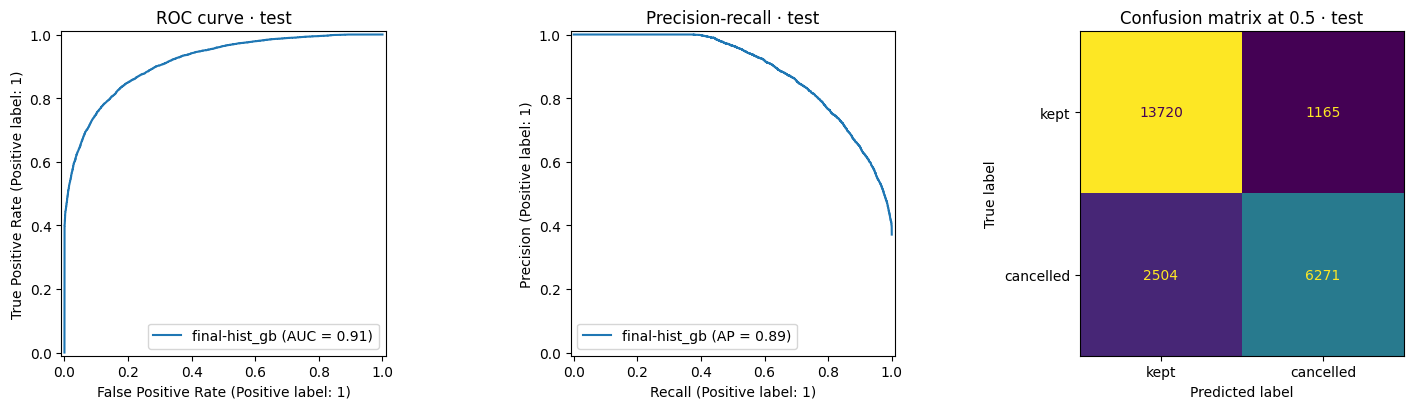

time: 305 ms (started: 2026-09-28 10:49:58 +05:30)


In [17]:
proba_test = final_pipe.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[0], name=final_run.info.run_name)
PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[1], name=final_run.info.run_name)
ConfusionMatrixDisplay.from_predictions(
    y_test, (proba_test >= 0.5).astype(int), display_labels=["kept", "cancelled"], ax=axes[2], colorbar=False
)
axes[0].set_title("ROC curve · test")
axes[1].set_title("Precision-recall · test")
axes[2].set_title("Confusion matrix at 0.5 · test")
fig.tight_layout()

with mlflow.start_run(run_id=final_run.info.run_id):
    mlflow.log_figure(fig, "plots/test_evaluation.png")

### Reports and tables

**Text-shaped results go in as files the UI can preview: JSON, Markdown, CSV.**

- `log_dict` → JSON · `log_text` → any text file; the extension decides how the UI shows it.
- `confident_mistakes.csv`: the 50 test bookings the model got most confidently wrong — where error analysis starts.

In [18]:
report = classification_report(
    y_test, (proba_test >= 0.5).astype(int), target_names=["kept", "cancelled"], output_dict=True
)

wrong = (proba_test >= 0.5) != (y_test == 1)
mistakes = (
    X_test[wrong]
    .assign(is_canceled=y_test[wrong], p_cancel=proba_test[wrong].round(3))
    .sort_values("p_cancel", key=lambda p: (p - 0.5).abs(), ascending=False)
    .head(50)
)

summary = f"""# Final model: {best_params['model_type']}

- Selected from sweep run `{best_run_id}`: best validation ROC-AUC under the 50 MB budget.
- Trained on {len(X_trainval):,} bookings (train + validation); scored once on {len(X_test):,} test bookings.

| test metric | value |
|---|---|
""" + "\n".join(f"| {name} | {value:.4f} |" for name, value in test_metrics.items())

with mlflow.start_run(run_id=final_run.info.run_id):
    mlflow.log_dict(report, "eval/classification_report.json")
    mlflow.log_text(mistakes.to_csv(index=False), "eval/confident_mistakes.csv")
    mlflow.log_text(summary, "eval/summary.md")

print(summary)

# Final model: hist_gb

- Selected from sweep run `bb6970744d8c405aa3c9d99f348295b4`: best validation ROC-AUC under the 50 MB budget.
- Trained on 94,640 bookings (train + validation); scored once on 23,660 test bookings.

| test metric | value |
|---|---|
| test_roc_auc | 0.9139 |
| test_pr_auc | 0.8887 |
| test_f1 | 0.7737 |
| test_precision | 0.8433 |
| test_recall | 0.7146 |
time: 23.1 ms (started: 2026-09-28 10:49:59 +05:30)


### Find them — in the UI

**Run `final-hist_gb` → Artifacts: every file is previewed in place.**

- `plots/test_evaluation.png` renders as an image, `eval/confident_mistakes.csv` as a sortable table, `eval/summary.md` as formatted Markdown, the JSON as text.
- `config.json` is the same kind of file P4 loaded from the sweep run.

### …and pull them back from code

**Artifacts are addressable by `runs:/<run_id>/<path>`, from any machine that can reach the store.**

- `MlflowClient().list_artifacts(run_id, path)` lists; `mlflow.artifacts.load_dict` / `load_text` / `load_image` read; `mlflow.artifacts.download_artifacts(run_id=..., artifact_path=..., dst_path=...)` copies to disk.

In [19]:
client = MlflowClient()
print([artifact.path for artifact in client.list_artifacts(final_run.info.run_id, "eval")])

report = mlflow.artifacts.load_dict(f"runs:/{final_run.info.run_id}/eval/classification_report.json")
pd.DataFrame(report).T.round(3)

['eval/classification_report.json', 'eval/confident_mistakes.csv', 'eval/summary.md']


,precision,recall,f1-score,support
kept,0.846,0.922,0.882,14885.000
cancelled,0.843,0.715,0.774,8775.000
accuracy,0.845,0.845,0.845,0.845
macro avg,0.844,0.818,0.828,23660.000
weighted avg,0.845,0.845,0.842,23660.000


time: 18.6 ms (started: 2026-09-28 10:49:59 +05:30)


💬 **Think about it** — What would a reviewer still ask for before approving this model: results per hotel? calibration? feature importance? Each one is a single `log_*` call into this run.

✍️ **Try it** — Log test ROC-AUC per hotel as `eval/by_hotel.csv` in the final run.

<details><summary>Answer</summary>

```python
by_hotel = (
    X_test.assign(y=y_test, p=proba_test)
    .groupby("hotel")[["y", "p"]]
    .apply(lambda g: roc_auc_score(g.y, g.p))
    .rename("test_roc_auc")
    .reset_index()
)
with mlflow.start_run(run_id=final_run.info.run_id):
    mlflow.log_text(by_hotel.to_csv(index=False), "eval/by_hotel.csv")
```

</details>

## P6 · Log the model: signature and input example

```
setup ✓ → problem ✓ → first run ✓ → sweep ✓ → compare ✓ → artifacts ✓ → [▶ LOG MODEL]
→ load model → autolog → train.py → practice → wrap-up
```

*You are here → **Part 6 of 11**: package the pipeline together with its input contract.*

**`log_model` packages the whole pipeline with its input contract, so anyone can reload it without your code.**

- Log the **Pipeline**, not the bare estimator: imputation and one-hot encoding travel with the model.
- **Signature** — input columns and types, plus the output type. Enforced when the model is called (P7).
- **Input example** — a few real rows saved beside the model: documentation and a smoke test in one.

In [20]:
signature = infer_signature(X_trainval, final_pipe.predict(X_trainval))
signature

/Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


inputs: 
  ['lead_time': long (required), 'stays_in_weekend_nights': long (required), 'stays_in_week_nights': long (required), 'adults': long (required), 'children': double (optional), 'babies': long (required), 'is_repeated_guest': long (required), 'previous_cancellations': long (required), 'previous_bookings_not_canceled': long (required), 'days_in_waiting_list': long (required), 'adr': double (required), 'required_car_parking_spaces': long (required), 'total_of_special_requests': long (required), 'hotel': string (required), 'meal': string (required), 'market_segment': string (required), 'distribution_channel': string (required), 'reserved_room_type': string (required), 'deposit_type': string (required), 'customer_type': string (required)]
outputs: 
  [Tensor('int64', (-1,))]
params: 
  None

time: 1.13 s (started: 2026-09-28 10:49:59 +05:30)


**The signature froze the training data's dtypes.**

- `long` for integer columns, `double` for `adr`, `string` for categories. Output `int64`: the class labels `predict` returns.
- `children` is `double (optional)`: the training data had missing values there, so the contract already allows them.
- The integer columns got no such allowance. The `UserWarning` above is MLflow predicting a production bug: an integer column can't hold a missing value. Keep it in mind for P7.

In [21]:
with mlflow.start_run(run_id=final_run.info.run_id):
    model_info = mlflow.sklearn.log_model(
        final_pipe,
        name="model",
        signature=signature,
        input_example=X_trainval.head(5),
        serialization_format="cloudpickle",
    )

print("model URI:", model_info.model_uri)
print("model ID :", model_info.model_id)
print("run ID   :", model_info.run_id)

2026/09/28 10:50:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


model URI: models:/m-90cab04be6aa48789c3597f1b716b594
model ID : m-90cab04be6aa48789c3597f1b716b594
run ID   : 09abc5abfcb44b7ea43d6b39fb4eba59
time: 3.74 s (started: 2026-09-28 10:50:00 +05:30)


### Why `serialization_format="cloudpickle"`

**MLflow 3.16 saves scikit-learn models with skops by default, and skops refuses any type it can't verify — this pipeline contains two.**

- Default (`skops`): safe to load, but on this pipeline `log_model` stops with *"The saved sklearn model references untrusted types"* (numpy's `dtype` from the imputer, sklearn's own tree classes) until each is allow-listed with `skops_trusted_types=[...]`.
- `cloudpickle` saves any Python object, and it's what autologging uses (P8). The WARNING it prints is true: unpickling can run code, so only load models from a store you trust.

### What got stored

**In MLflow 3 a logged model is its own entity, `models:/<model_id>`, linked to the run that produced it.**

- **In the UI:** run **final-hist_gb** → **Overview**: the metrics table gained a **Models** column, and **Logged models (1)** appears under the parameters. The sidebar's **Models** page lists every logged model in the experiment with the run it came from.
- The run's metrics were attached to the model automatically — including the ones logged before the model existed.
- The files live under `mlruns/<experiment_id>/models/<model_id>/`, not in the run's Artifacts tab.

In [22]:
logged_model = mlflow.get_logged_model(model_info.model_id)

print("name   :", logged_model.name, "| source run:", logged_model.source_run_id)
print("metrics:", {m.key: round(m.value, 4) for m in logged_model.metrics})
print("files  :", [Path(f.path).name for f in mlflow.artifacts.list_artifacts(artifact_uri=logged_model.artifact_location)])

name   : model | source run: 09abc5abfcb44b7ea43d6b39fb4eba59
metrics: {'fit_time_s': 17.235, 'model_size_mb': 3.1524, 'test_roc_auc': 0.9139, 'test_pr_auc': 0.8887, 'test_f1': 0.7737, 'test_precision': 0.8433, 'test_recall': 0.7146}
files  : ['MLmodel', 'conda.yaml', 'input_example.json', 'model.pkl', 'python_env.yaml', 'requirements.txt', 'serving_input_example.json']
time: 2.4 ms (started: 2026-09-28 10:50:04 +05:30)


- `MLmodel` — how to load it: flavors (`python_function`, `sklearn`), signature, Python version.
- `requirements.txt`, `python_env.yaml`, `conda.yaml` — the environment it needs.
- `input_example.json`, `serving_input_example.json` — the example rows, raw and in the request format a serving endpoint expects.

## P7 · Load the model and score next week's arrivals

```
setup ✓ → problem ✓ → first run ✓ → sweep ✓ → compare ✓ → artifacts ✓ → log model ✓
→ [▶ LOAD MODEL] → autolog → train.py → practice → wrap-up
```

*You are here → **Part 7 of 11**: reload it from a URI and score bookings whose outcome is unknown.*

**A model URI is all a consumer needs — no training code, no file paths.**

- `models:/<model_id>` and `runs:/<run_id>/model` point at the same logged model.
- **pyfunc** (`mlflow.pyfunc.load_model`): one generic `predict(DataFrame)` for every framework, with the signature enforced. Serving tools use this.
- **sklearn flavor** (`mlflow.sklearn.load_model`): the original `Pipeline` object — `predict_proba`, `named_steps`, everything.

In [23]:
upcoming = pd.read_csv("data/upcoming_arrivals.csv")

print(f"{len(upcoming):,} bookings arriving {upcoming.arrival_date.min()} → {upcoming.arrival_date.max()}, outcome unknown")
upcoming.head(3)

1,090 bookings arriving 2017-08-25 → 2017-08-31, outcome unknown


,booking_id,arrival_date,hotel,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,...,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
0,BK218301,2017-08-25,City Hotel,239,0,1,2,2.0,0,BB,...,0,0,0,F,No Deposit,Transient,0,189.0,0,1
1,BK218302,2017-08-25,City Hotel,457,0,2,2,0.0,0,HB,...,0,0,0,A,No Deposit,Transient-Party,0,122.4,0,1
2,BK218303,2017-08-25,City Hotel,457,0,2,2,0.0,0,BB,...,0,0,0,A,No Deposit,Transient-Party,0,80.0,0,0


time: 7.01 ms (started: 2026-09-28 10:50:04 +05:30)


In [24]:
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)
print(loaded_model)

loaded_model.predict(upcoming)[:10]

2026/09/28 10:50:04 WARNING mlflow.models.utils: Found extra inputs in the model input that are not defined in the model signature: `['arrival_date', 'booking_id']`. These inputs will be ignored.


mlflow.pyfunc.loaded_model:
  artifact_path: /Users/shivam13juna/Documents/scaler/AIML_mlops/ref/lec 5 Experiment
    tracking with ML Flow 1/mlruns/1/models/m-90cab04be6aa48789c3597f1b716b594/artifacts
  flavor: mlflow.sklearn
  run_id: 09abc5abfcb44b7ea43d6b39fb4eba59



array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0])

time: 57.6 ms (started: 2026-09-28 10:50:04 +05:30)


- pyfunc dropped `booking_id` and `arrival_date` itself — they aren't in the signature (the WARNING says so).
- It returns class labels, because the signature's output is `predict`. For probabilities, load the sklearn flavor — or log the model with `pyfunc_predict_fn="predict_proba"` and a signature built from `predict_proba`.

In [25]:
sk_model = mlflow.sklearn.load_model(model_info.model_uri)
print(type(sk_model).__name__, "with steps", list(sk_model.named_steps))

risk = upcoming.assign(p_cancel=sk_model.predict_proba(upcoming[FEATURES])[:, 1].round(3))
print(f"{(risk.p_cancel >= 0.5).sum()} of {len(risk):,} upcoming bookings at p_cancel ≥ 0.5")

(
    risk.sort_values("p_cancel", ascending=False)
    .drop_duplicates(subset=FEATURES)  # a group booking arrives as many identical rows
    [["booking_id", "arrival_date", "hotel", "lead_time", "deposit_type", "market_segment", "p_cancel"]]
    .head(10)
)

Pipeline with steps ['prep', 'model']
278 of 1,090 upcoming bookings at p_cancel ≥ 0.5


,booking_id,arrival_date,hotel,lead_time,deposit_type,market_segment,p_cancel
742,BK219043,2017-08-29,City Hotel,521,Non Refund,Offline TA/TO,1.000
1048,BK219349,2017-08-31,Resort Hotel,350,No Deposit,Online TA,0.992
927,BK219228,2017-08-30,Resort Hotel,357,No Deposit,Online TA,0.991
686,BK218987,2017-08-28,Resort Hotel,175,Refundable,Online TA,0.988
470,BK218771,2017-08-27,Resort Hotel,344,No Deposit,Online TA,0.978
699,BK219000,2017-08-28,Resort Hotel,237,No Deposit,Online TA,0.977
14,BK218315,2017-08-25,City Hotel,457,No Deposit,Offline TA/TO,0.976
322,BK218623,2017-08-26,Resort Hotel,181,No Deposit,Online TA,0.968
981,BK219282,2017-08-31,City Hotel,245,No Deposit,Online TA,0.962
23,BK218324,2017-08-25,City Hotel,235,No Deposit,Online TA,0.957


time: 40.2 ms (started: 2026-09-28 10:50:04 +05:30)


### The signature at work

**pyfunc checks every request against the signature — bad input fails loudly instead of producing quiet garbage.**

In [26]:
request = upcoming[FEATURES].head(3)
checks = {
    "unchanged request": request,
    "missing column (deposit_type)": request.drop(columns=["deposit_type"]),
    "text in a number column (lead_time)": request.astype({"lead_time": str}),
    "one missing value (lead_time = NaN)": request.assign(lead_time=[np.nan, 30, 120]),
}

for label, frame in checks.items():
    try:
        loaded_model.predict(frame)
        print(f"✅ {label}: accepted")
    except Exception as e:
        print(f"❌ {label}: {str(e).rsplit('Error: ', 1)[-1]}")

✅ unchanged request: accepted
❌ missing column (deposit_type): Model is missing inputs ['deposit_type'].
❌ text in a number column (lead_time): Incompatible input types for column lead_time. Can not safely convert object to int64.
❌ one missing value (lead_time = NaN): Incompatible input types for column lead_time. Can not safely convert float64 to int64. Hint: the type mismatch is likely caused by missing values. Integer columns in python can not represent missing values and are therefore encoded as floats. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
time: 33.5 ms (started: 2026-09-28 10:50:04 +05:30)


**The first three results are exactly what a contract is for. The fourth is the P6 warning coming true.**

- ❌ **Missing column / text in a number column** — rejected before the model runs.
- ❌ **One missing `lead_time`** — the pipeline's imputer would have filled it, but the signature says `long`, and a column holding `NaN` is `float64`.
- **Fix it at training time:** train the numeric features as `float64`. The contract then says `double`, and a missing value reaches the imputer. The next cell does that for the rest of this notebook; `train.py` (P9) does it too.

In [27]:
X_train, X_val, X_test = (frame.astype({c: "float64" for c in NUMERIC}) for frame in (X_train, X_val, X_test))
X_train.dtypes.value_counts()

float64    13
object      7
Name: count, dtype: int64

time: 8.72 ms (started: 2026-09-28 10:50:04 +05:30)


✍️ **Try it** — Load the same model through `runs:/<run_id>/model` and confirm it predicts exactly what `loaded_model` does.

<details><summary>Answer</summary>

```python
same = mlflow.pyfunc.load_model(f"runs:/{final_run.info.run_id}/model")
(same.predict(upcoming[FEATURES]) == loaded_model.predict(upcoming[FEATURES])).all()
```

</details>

## P8 · Autologging

```
setup ✓ → problem ✓ → first run ✓ → sweep ✓ → compare ✓ → artifacts ✓ → log model ✓
→ load model ✓ → [▶ AUTOLOG] → train.py → practice → wrap-up
```

*You are here → **Part 8 of 11**: let autolog write the logging code, and see what it misses.*

**`mlflow.sklearn.autolog()` patches `fit()`: a run, every parameter, training metrics and the model are logged without a single `log_*` call.**

- `mlflow.autolog()` does the same for every supported library at once (XGBoost, LightGBM, PyTorch Lightning, Keras, …).
- Below: the winning config again, with nothing but `fit()`.

In [28]:
mlflow.sklearn.autolog()

pipe = build_pipeline(best_params).fit(X_train, y_train)  # no mlflow.* call anywhere

autolog_run = mlflow.last_active_run()
print("autolog created run:", autolog_run.info.run_name, "|", autolog_run.info.run_id)

2026/09/28 10:50:05 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '28f44f3199234dac94c7c51d5ca2a277', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/09/28 10:50:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


autolog created run: languid-squid-382 | 28f44f3199234dac94c7c51d5ca2a277
time: 17.8 s (started: 2026-09-28 10:50:04 +05:30)


In [29]:
logged = mlflow.get_run(autolog_run.info.run_id)
examples = ["model__max_leaf_nodes", "model__l2_regularization", "prep__num__simpleimputer__strategy", "prep__cat__dtype"]

print(len(logged.data.params), "params, e.g.", {key: logged.data.params[key] for key in examples})
print("metrics  :", {k: round(v, 4) for k, v in logged.data.metrics.items()})
print("tags     :", {k: v for k, v in logged.data.tags.items() if not k.startswith("mlflow.source")})
print("artifacts:", [artifact.path for artifact in client.list_artifacts(autolog_run.info.run_id)])
print("datasets :", [(d.dataset.name, d.dataset.digest) for d in logged.inputs.dataset_inputs])
print("models   :", [output.model_id for output in logged.outputs.model_outputs])

60 params, e.g. {'model__max_leaf_nodes': '127', 'model__l2_regularization': '0.0', 'prep__num__simpleimputer__strategy': 'median', 'prep__cat__dtype': "<class 'numpy.float64'>"}
metrics  : {'training_precision_score': 0.8754, 'training_recall_score': 0.8746, 'training_f1_score': 0.8724, 'training_accuracy_score': 0.8746, 'training_log_loss': 0.2795, 'training_roc_auc': 0.9515, 'training_score': 0.8746}
tags     : {'mlflow.user': 'shivam13juna', 'mlflow.autologging': 'sklearn', 'mlflow.runName': 'languid-squid-382', 'estimator_name': 'Pipeline', 'estimator_class': 'sklearn.pipeline.Pipeline'}
artifacts: ['estimator.html', 'training_confusion_matrix.png', 'training_precision_recall_curve.png', 'training_roc_curve.png']
datasets : [('dataset', '9062f981')]
models   : ['m-0eec586476d7455fa9dbc4ca63f7a0a6']
time: 6.34 ms (started: 2026-09-28 10:50:22 +05:30)


**Autolog records what `fit()` can see — which is not what you pick models by.**

- **Params** — every constructor argument of every pipeline step (`prep__num__simpleimputer__strategy`, `model__max_leaf_nodes`, …): complete, and dozens of them.
- **Metrics** — `training_*` only, scored on the training data. A training ROC-AUC says nothing about new bookings.
- **Artifacts** — training confusion matrix, ROC and precision-recall plots, and `estimator.html` (the pipeline diagram).
- **Also** — the model, the training data as a dataset (digest only), and a random run name.
- **Cost** — it scores the training set and saves a model on every `fit()`: this cell took longer than the same fit in the sweep.
- It also tries to catch `sklearn.metrics` calls made after `fit()` ("post-training metrics"), but only in narrow cases — a `roc_auc_score` on `predict_proba(...)[:, 1]` isn't picked up. Log the numbers you decide with yourself.

### Autolog plus your own metrics, in one run

**Start the run yourself: autolog fills in the boilerplate, you add the numbers you decide with.**

In [30]:
with mlflow.start_run(run_name="hist_gb-autolog+val") as run:
    pipe = build_pipeline(best_params).fit(X_train, y_train)  # autolog: params, training metrics, model
    mlflow.log_metrics(evaluate(pipe, X_val, y_val))          # you: the metrics you select on
    mlflow.set_tag("stage", "autolog-demo")

sorted(mlflow.get_run(run.info.run_id).data.metrics)

2026/09/28 10:50:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


['training_accuracy_score',
 'training_f1_score',
 'training_log_loss',
 'training_precision_score',
 'training_recall_score',
 'training_roc_auc',
 'training_score',
 'val_f1',
 'val_pr_auc',
 'val_precision',
 'val_recall',
 'val_roc_auc']

time: 17.2 s (started: 2026-09-28 10:50:22 +05:30)


### Tuning: parent and child runs

**Under autolog, a `GridSearchCV` becomes one parent run — best params, best CV score, `cv_results.csv` — with a child run per candidate.**

- Children are capped at `max_tuning_runs=5` by default (the best five); this grid has four.
- **In the UI:** the parent row **rf-grid-search** has a **+** beside its name; click it to show the children, which got MLflow-generated names.
- In code, `tags.mlflow.parentRunId` finds them.

In [31]:
grid = GridSearchCV(
    build_pipeline({"model_type": "random_forest", "n_estimators": 100}),
    param_grid={"model__max_depth": [8, 12], "model__min_samples_leaf": [1, 20]},
    scoring="roc_auc",
    cv=3,
)
with mlflow.start_run(run_name="rf-grid-search") as parent:
    grid.fit(X_train, y_train)

children = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string=f"tags.mlflow.parentRunId = '{parent.info.run_id}'",
    order_by=["metrics.mean_test_score DESC"],
)
print("parent best_cv_score:", round(mlflow.get_run(parent.info.run_id).data.metrics["best_cv_score"], 4))
children[["tags.mlflow.runName", "params.model__max_depth", "params.model__min_samples_leaf", "metrics.mean_test_score"]]

2026/09/28 10:50:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/28 10:50:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/28 10:50:49 INFO mlflow.sklearn.utils: Logging the 4 best runs, no runs will be omitted.


parent best_cv_score: 0.8887


,tags.mlflow.runName,params.model__max_depth,params.model__min_samples_leaf,metrics.mean_test_score
0,brawny-jay-957,12,1,0.888674
1,suave-rat-894,12,20,0.882499
2,shivering-croc-410,8,1,0.872930
3,angry-hog-322,8,20,0.871953


time: 11.3 s (started: 2026-09-28 10:50:39 +05:30)


In [32]:
mlflow.sklearn.autolog(disable=True)  # back to explicit logging for the rest of the notebook

time: 2.1 ms (started: 2026-09-28 10:50:50 +05:30)


### Manual logging vs autologging

| | Manual logging | Autologging |
|---|---|---|
| **Setup** | a `log_*` call per item | one line before `fit()` |
| **Params** | the ones you chose to record | every constructor argument, dozens |
| **Metrics** | whatever you compute: validation, test, business constraints | training-set metrics (+ fragile post-training capture) |
| **Artifacts** | the plots and reports that matter for the decision | standard training plots, `estimator.html` |
| **Model** | you call `log_model` with a signature and an example | logged on every `fit()` |
| **Cost** | only what you log | re-scores the training set and saves a model per fit |
| **Best for** | final and production training code | exploration, tuning sweeps, unfamiliar frameworks |

**Rule of thumb: autolog for the boilerplate, manual for the numbers you make decisions with — in the same run.**

## P9 · A real training script: `train.py`

```
setup ✓ → problem ✓ → first run ✓ → sweep ✓ → compare ✓ → artifacts ✓ → log model ✓
→ load model ✓ → autolog ✓ → [▶ TRAIN.PY] → practice → wrap-up
```

*You are here → **Part 9 of 11**: move training into a script that tracks itself.*

**Move the loop body into a script, and every training run — laptop, cron job or CI — is tracked the same way.**

- `train.py` sits beside this notebook; open it. One self-contained file, nothing MLflow-specific beyond what P2–P6 used.
- What it adds over the notebook: flags instead of edited cells, the tracking URI from the environment, the data file recorded as a dataset (path + digest), float64 numeric features, and the git commit.

The lines that make it tracked:

```python
mlflow.set_tracking_uri(os.environ.get("MLFLOW_TRACKING_URI", "sqlite:///mlflow.db"))
mlflow.set_experiment(args.experiment)

with mlflow.start_run(run_name=args.run_name) as run:
    mlflow.log_params(config)
    mlflow.log_dict(config, "config.json")
    mlflow.set_tags({"stage": "pipeline", "entry_point": "train.py"})
    with warnings.catch_warnings():  # two MLflow 3.16 dataset-logging warnings (see train.py)
        warnings.simplefilter("ignore")
        dataset = mlflow.data.from_pandas(bookings, source=str(DATA), name=DATA.name, targets="is_canceled")
        mlflow.log_input(dataset, context="training")
    ...
    model_info = mlflow.sklearn.log_model(pipe, name="model", signature=..., input_example=...,
                                          serialization_format="cloudpickle")

print(f"run_id       = {run.info.run_id}")
print(f"model_uri    = {model_info.model_uri}")
```

In [33]:
!python train.py --learning-rate 0.1 --max-leaf-nodes 127 --max-iter 300

2026/09/28 10:51:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


tracking_uri = sqlite:///mlflow.db
run_id       = 64e6608fa97049f0a70072de6561d3dc
model_uri    = models:/m-2867f028e0cb43c5bc630a445cbe0999


time: 26.1 s (started: 2026-09-28 10:50:50 +05:30)


- The flags are P4's winner — also `train.py`'s defaults, so a bare `python train.py` trains the same model.
- No tracking URI was passed, yet the run landed in this notebook's store: `mlflow.set_tracking_uri()` also exported `MLFLOW_TRACKING_URI`, and child processes inherit it.
- `python` here has to be the environment this kernel runs in (an activated venv or conda env).

In [34]:
pipeline_run = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="tags.stage = 'pipeline'",
    order_by=["attributes.start_time DESC"],
    max_results=1,
    output_format="list",
)[0]

print("source    :", pipeline_run.data.tags["mlflow.source.name"])
print("git commit:", pipeline_run.data.tags.get("mlflow.source.git.commit"))
for dataset_input in pipeline_run.inputs.dataset_inputs:
    dataset = dataset_input.dataset
    print("dataset   :", dataset.name, "| digest", dataset.digest, "|", dataset.profile)

source    : train.py
git commit: e4fc4701f346eb0a8fd12d75cebbcfff67cd1856
dataset   : bookings_2015_2017.csv.gz | digest 594f9222 | {"num_rows": 118300, "num_elements": 2720900}
time: 8.29 ms (started: 2026-09-28 10:51:16 +05:30)


### Same config, same data — same number?

**Runs with test metrics: the notebook's final run and the script's run.**

In [35]:
mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="metrics.test_roc_auc > 0",
)[["tags.mlflow.runName", "tags.stage", "tags.mlflow.source.name", "metrics.test_roc_auc", "metrics.test_f1", "run_id"]]

,tags.mlflow.runName,tags.stage,tags.mlflow.source.name,metrics.test_roc_auc,metrics.test_f1,run_id
0,final-hist_gb,pipeline,train.py,0.913853,0.773672,64e6608fa97049f0a70072de6561d3dc
1,final-hist_gb,final,/Users/shivam13juna/Documents/virtual_envs/dev...,0.913853,0.773672,09abc5abfcb44b7ea43d6b39fb4eba59


time: 8.37 ms (started: 2026-09-28 10:51:16 +05:30)


**Same config, same data, same seed → the same test score, from a notebook and from a script.**

- That equality is what reproducible means — and the tracking store is how you prove the model you ship is the one you evaluated.
- The script's row carries what the notebook's can't: a real source file and a git commit.

### The float64 fix, checked

**The script trained on float64 numerics, so its model's contract says `double`.**

In [36]:
script_model = mlflow.pyfunc.load_model(f"runs:/{pipeline_run.info.run_id}/model")
floats = upcoming[FEATURES].head(3).astype({c: "float64" for c in NUMERIC})
checks = {
    "floats, one missing lead_time": floats.assign(lead_time=[np.nan, 30.0, 120.0]),
    "ints, straight from the CSV": upcoming[FEATURES].head(3),
}

for label, frame in checks.items():
    try:
        script_model.predict(frame)
        print(f"✅ {label}: accepted")
    except Exception as e:
        print(f"❌ {label}: {str(e).rsplit('Error: ', 1)[-1]}")

✅ floats, one missing lead_time: accepted
❌ ints, straight from the CSV: Incompatible input types for column lead_time. Can not safely convert int64 to float64.
time: 77.5 ms (started: 2026-09-28 10:51:16 +05:30)


- ✅ A missing `lead_time` now reaches the imputer instead of failing the request.
- ❌ Plain `int64` input is rejected: MLflow won't silently turn `int64` into `float64` (large integers lose precision). The contract is now "numeric = double" — whoever calls the model casts at the boundary.

💬 **Think about it** — What else belongs in this script before it runs every night: a data-validation step? a check that the new test ROC-AUC beats the current model's? Where in MLflow would each result go?

## P10 · What bites in practice

```
setup ✓ → problem ✓ → first run ✓ → sweep ✓ → compare ✓ → artifacts ✓ → log model ✓
→ load model ✓ → autolog ✓ → train.py ✓ → [▶ PRACTICE] → wrap-up
```

*You are here → **Part 10 of 11**: run IDs, run status, one tracking URI, local vs shared.*

**Four habits decide whether a tracking store stays trustworthy.**

### 1 · Run IDs vs run names

**Names are labels; IDs are identities.**

In [37]:
same_name = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string=f"attributes.run_name = '{final_run.info.run_name}'",
)
same_name[["run_id", "tags.mlflow.runName", "tags.stage", "tags.mlflow.source.name", "start_time"]]

,run_id,tags.mlflow.runName,tags.stage,tags.mlflow.source.name,start_time
0,64e6608fa97049f0a70072de6561d3dc,final-hist_gb,pipeline,train.py,2026-09-28 05:20:53.558000+00:00
1,09abc5abfcb44b7ea43d6b39fb4eba59,final-hist_gb,final,/Users/shivam13juna/Documents/virtual_envs/dev...,2026-09-28 05:19:41.561000+00:00


time: 7.92 ms (started: 2026-09-28 10:51:16 +05:30)


- Two different runs share the name `final-hist_gb` — the notebook's and the script's. A nightly job would add one more every night.
- MLflow never enforces unique names. Leave `run_name` out and it invents one — like the autolog run in P8.
- In code, pass IDs around — `best_run_id`, `runs:/<run_id>/...`, `models:/<model_id>`. Names are for people.

### 2 · Run status

**A run's status tells you whether its numbers can be trusted.**

| Status | Meaning |
|---|---|
| `RUNNING` | started and not ended — still going, or its process died |
| `FINISHED` | ended normally |
| `FAILED` | the code raised inside the run; the `with` block records it |
| `KILLED` | ended as killed — set explicitly, e.g. `mlflow.end_run(status="KILLED")` |

In [38]:
try:
    with mlflow.start_run(run_name="bad-config") as failed_run:
        params = {"model_type": "random_forest", "max_depth": -1}
        mlflow.log_params(params)
        build_pipeline(params).fit(X_train, y_train)
except Exception as e:
    print(f"training failed: {type(e).__name__}")

failed = mlflow.get_run(failed_run.info.run_id)
print("status:", failed.info.status, "| params kept:", failed.data.params)

training failed: InvalidParameterError
status: FAILED | params kept: {'model_type': 'random_forest', 'max_depth': '-1'}
time: 102 ms (started: 2026-09-28 10:51:16 +05:30)


**Without a `with` block, nothing ends the run — and the next `start_run()` refuses to begin.**

In [39]:
dangling = mlflow.start_run(run_name="forgot-to-end")  # no `with`
print("status:", mlflow.get_run(dangling.info.run_id).info.status)

try:
    mlflow.start_run(run_name="next-idea")
except Exception as e:
    print(f"{type(e).__name__}: {e}")

mlflow.end_run()
print("after mlflow.end_run():", mlflow.get_run(dangling.info.run_id).info.status)

status: RUNNING
Exception: Run with UUID 7e87a95bd04e4b4c8e899555b2cc224d is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True
after mlflow.end_run(): FINISHED
time: 13 ms (started: 2026-09-28 10:51:16 +05:30)


- A failed run keeps its params, so you can see exactly which config broke.
- A crashed kernel or a killed job leaves runs `RUNNING` for good — that's why P4's leaderboard filtered on `attributes.status = 'FINISHED'`.
- In notebooks, prefer `with mlflow.start_run(...)`; to add to a run later, reopen it with `start_run(run_id=...)`, as P5 did.

### 3 · Tracking-URI consistency

**The same code logs to a different store when it runs from a different directory — and nothing warns you.**

- Below, `train.py` runs from `elsewhere/`, a folder standing in for a CI checkout, a cron job or a colleague's shell. Delete it when you're done.
- It inherits this notebook's `MLFLOW_TRACKING_URI=sqlite:///mlflow.db` — a *relative* path.
- `--max-iter 50` keeps it fast; what matters is where the run goes.

In [40]:
before = len(mlflow.search_runs(experiment_names=["booking-cancellations"]))

!mkdir -p elsewhere && cd elsewhere && python ../train.py --max-iter 50 --run-name from-another-dir

print("runs in this notebook's store:", before, "→", len(mlflow.search_runs(experiment_names=["booking-cancellations"])))
print("files in elsewhere/          :", sorted(p.name for p in Path("elsewhere").iterdir()))

2026/09/28 10:51:19 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/28 10:51:19 INFO mlflow.store.db.utils: Updating database tables


2026/09/28 10:51:19 INFO mlflow.tracking.fluent: Experiment with name 'booking-cancellations' does not exist. Creating a new experiment.


2026/09/28 10:51:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


tracking_uri = sqlite:///mlflow.db
run_id       = 1d5ed8a9a41b407a90d780178ecc0f44
model_uri    = models:/m-ce75896a80c44a348356c375a58188df


runs in this notebook's store:

 19 → 19
files in elsewhere/          : ['mlflow.db', 'mlruns']
time: 14.1 s (started: 2026-09-28 10:51:16 +05:30)


**The run exists — in a brand-new `mlflow.db` inside `elsewhere/`. Fix: an absolute URI, set in the environment.**

- The script's own log gave it away — `Creating initial MLflow database tables…` and `Experiment with name 'booking-cancellations' does not exist` — two lines that are easy to miss in a CI log.
- `$absolute_uri` in a `!` line is the Python variable: IPython substitutes it before the shell runs.

In [41]:
absolute_uri = f"sqlite:///{Path.cwd() / 'mlflow.db'}"
print(absolute_uri)
before = len(mlflow.search_runs(experiment_names=["booking-cancellations"]))

!cd elsewhere && MLFLOW_TRACKING_URI="$absolute_uri" python ../train.py --max-iter 50 --run-name from-another-dir

print("runs in this notebook's store:", before, "→", len(mlflow.search_runs(experiment_names=["booking-cancellations"])))

sqlite:////Users/shivam13juna/Documents/scaler/AIML_mlops/ref/lec 5 Experiment tracking with ML Flow 1/mlflow.db


2026/09/28 10:51:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


tracking_uri = sqlite:////Users/shivam13juna/Documents/scaler/AIML_mlops/ref/lec 5 Experiment tracking with ML Flow 1/mlflow.db
run_id       = 5bdc5e8a0e344a5bb62dd5cedd2d69c4
model_uri    = models:/m-38942c500403435097f8ee521fcf6fc7


runs in this notebook's store: 19 → 20
time: 13.7 s (started: 2026-09-28 10:51:31 +05:30)


- `sqlite:///mlflow.db` means "`mlflow.db` in whatever directory I'm in". Every CI job, cron entry or colleague's terminal gets its own empty store.
- Fix it once: an absolute path — or better, a server URL — in `MLFLOW_TRACKING_URI`, set by the environment. `train.py` only falls back to a default.
- Print `mlflow.get_tracking_uri()` at the start of every job (`train.py` prints it at the end), so a misplaced run is a one-line diagnosis.

### 4 · Local store vs shared tracking server

**The code doesn't change between the two — only the tracking URI does.**

| | Local (this notebook) | Shared tracking server |
|---|---|---|
| **Tracking URI** | `sqlite:///mlflow.db` | `http://mlflow.internal:5000` |
| **Run metadata** | a SQLite file | PostgreSQL / MySQL |
| **Artifacts and models** | `./mlruns` on your disk | S3 / GCS / Azure Blob, proxied by the server |
| **Who sees the runs** | you, on this machine | the whole team |
| **Access control** | not needed | built-in basic auth (`--app-name basic-auth`) or a managed MLflow service |
| **Setup** | none | a service someone operates |

The server (someone runs this once, on a machine the team can reach):

```bash
mlflow server \
  --backend-store-uri postgresql://mlflow:<password>@db.internal:5432/mlflow \
  --artifacts-destination s3://mare-ml/mlflow-artifacts \
  --host 0.0.0.0 --port 5000
```

Every client:

```bash
export MLFLOW_TRACKING_URI=http://mlflow.internal:5000
python train.py        # unchanged
```

- With `--artifacts-destination`, clients upload artifacts through the server, so laptops and CI need no cloud credentials.
- The `mlflow ui` from P2 is already a small tracking server: `mlflow.set_tracking_uri("http://127.0.0.1:5001")` would read and write these same runs over HTTP.

## P11 · Wrap-up

```
setup ✓ → problem ✓ → first run ✓ → sweep ✓ → compare ✓ → artifacts ✓ → log model ✓
→ load model ✓ → autolog ✓ → train.py ✓ → practice ✓ → [▶ WRAP-UP]
```

*You are here → **Part 11 of 11**: where tracking ends, and what builds on it.*

### Tracking vs Model Registry vs serving

**This notebook stopped at tracking. The registry and serving both start from the model URI you now have.**

| | Experiment tracking | Model Registry | Serving / deployment |
|---|---|---|---|
| **Question** | what did we try, and how did it do? | which model is approved for production? | how do other systems call it? |
| **Unit** | experiment → run → metrics, artifacts, logged models | registered model → versions → aliases (`@champion`) | an endpoint or batch job running one version |
| **Typical calls** | `start_run`, `log_*`, `search_runs`, `log_model` | `mlflow.register_model(model_uri, name)`, set an alias | `mlflow models serve -m "models:/<name>@champion"`, a container, a managed endpoint |
| **Used by** | whoever trains models | reviewers, the release process | platform and application teams |
| **Here** | P2–P10 | next | next |

```mermaid
flowchart LR
    TRAIN(["notebook · train.py"])
    RUNS["Experiment tracking<br/>runs · params · metrics · artifacts"]
    LM["Logged model<br/>models:/m-…"]
    REG["Model Registry<br/>versions · alias @champion"]
    SERVE(["Serving<br/>REST endpoint · batch scoring"])
    TRAIN --> RUNS --> LM
    LM -- "register" --> REG
    REG -- "load by alias" --> SERVE
    classDef code fill:#e8f0fe,stroke:#4285f4,color:#174ea6
    classDef done fill:#f3e8fd,stroke:#9334e6,color:#681da8
    classDef next fill:#fff3e0,stroke:#ef6c00,color:#8a3800
    classDef endpoint fill:#e6f4ea,stroke:#34a853,color:#137333
    class TRAIN code
    class RUNS,LM done
    class REG next
    class SERVE endpoint
```

- 🟪 covered here · 🟧 the registry: next · 🟩 serving: after that.

### The workflow, end to end

**Ten calls cover almost everything in this notebook.**

```python
mlflow.set_tracking_uri(...)                          # where runs go            P2 (better: MLFLOW_TRACKING_URI)
mlflow.set_experiment("booking-cancellations")        # which problem            P2
with mlflow.start_run(run_name=..., description=...): # one training attempt     P2
    mlflow.log_params(config)                         # inputs, as strings       P2
    mlflow.log_dict(config, "config.json")            # inputs, typed            P3
    mlflow.set_tags({"stage": "sweep"})               # labels to filter on      P2
    mlflow.log_input(dataset, context="training")     # data lineage             P9
    mlflow.log_metrics(metrics, step=...)             # outputs, curves          P2 · P3
    mlflow.log_figure(fig, "plots/...png")            # evidence                 P5
    mlflow.sklearn.log_model(pipe, name="model", signature=..., input_example=...)   # P6
mlflow.search_runs(filter_string=..., order_by=[...])  # decide                   P4
mlflow.pyfunc.load_model("models:/<model_id>")         # use                      P7
```

### Recommendations for real projects

**Small habits, applied from the first run, keep a store useful a year later.**

- **One experiment per prediction problem**, named after the problem (`booking-cancellations`), not after a person or a date.
- **Set `MLFLOW_TRACKING_URI` in the environment**, as an absolute path or a server URL. Never rely on a relative path.
- **Tag runs by purpose** (`stage = sweep | final | pipeline`) so every search starts with a filter.
- **Log the config twice:** params for searching, `config.json` for reproducing.
- **Log the metrics you decide with yourself** — validation and test scores, plus deployment constraints (size, latency, cost). Autolog is a supplement.
- **Log the whole pipeline with a signature and an input example**, and choose numeric dtypes on purpose (`float64` where values can be missing).
- **Pass run IDs and model IDs between steps**, never names; filter automated searches on `attributes.status = 'FINISHED'`.
- **Keep artifacts purposeful:** plots, reports, samples — not full datasets, and never secrets. Anyone with access to the store can read them.
- **Move training into a script early:** it records the git commit and the dataset, and it runs anywhere with one environment variable.

### What comes next

**Everything below builds on the runs and model URIs you can now produce.**

- **Model Registry** — register a `models:/…` URI as a numbered version; aliases such as `@champion`; promotion and rollback.
- **Serving and deployment** — `mlflow models serve`, Docker images, batch scoring, managed endpoints.
- **Production tracking infrastructure** — a shared server on PostgreSQL, remote artifact stores (S3 / GCS / Azure), authentication and permissions.
- **Automation** — training pipelines in CI/CD, scheduled retraining, validation gates before a model is registered.
- **Evaluation and monitoring** — `mlflow.models.evaluate`, comparing a candidate against the current champion, drift checks.
- **GenAI in MLflow** — tracing, prompt versioning and LLM evaluation: the same tracking server, different things inside each run.